Resultados da Validação Cruzada (5 folds):
Random Forest: Acurácia média = 0.967 (± 0.021)
KNN: Acurácia média = 0.973 (± 0.025)
Árvore de Decisão: Acurácia média = 0.953 (± 0.034)


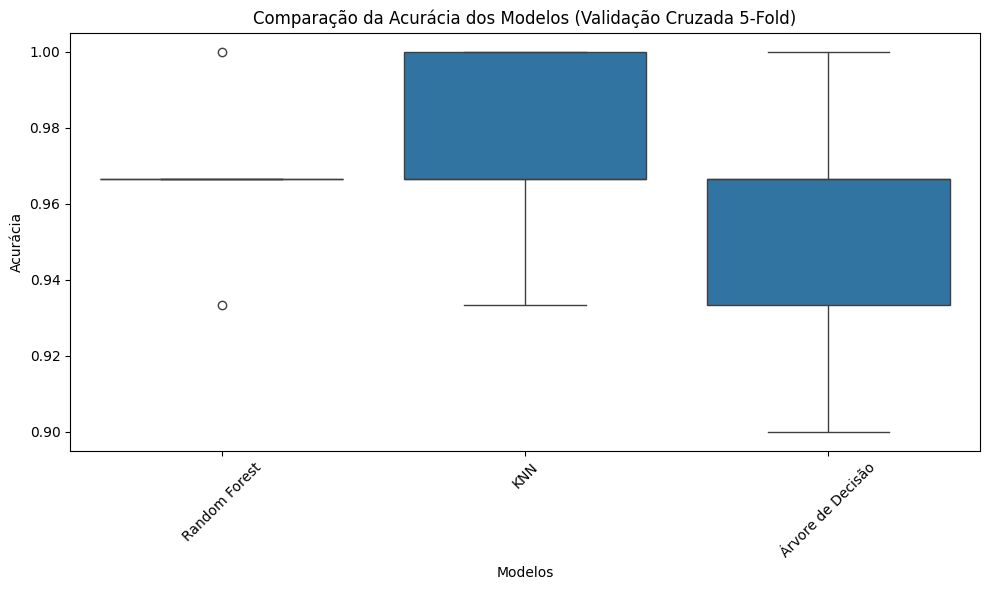

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

class ComparadorModelos:
    def __init__(self):
        """
        Carrega o dataset Iris, um conjunto clássico para classificação com 3 classes de flores
        (Setosa, Versicolor, Virginica) e 4 features (comprimento/sepiála/pétala).
        """
        iris = load_iris()
        self.X = iris.data
        self.y = iris.target

    def comparar_modelos(self):
        """
        Realiza validação cruzada de 5 folds para comparar a acurácia dos modelos.

        Diferenças entre os modelos (para estudantes de Engenharia):
        - Random Forest: Método ensemble (bagging + random features). Combina múltiplas árvores
          de decisão para reduzir variância e overfitting. Robusto a ruído e outliers.
          Complexidade: O(n log n) por árvore, mas paralelo.
        - KNN (K-Vizinhos Mais Próximos): Algoritmo 'lazy' (sem treino explícito).
          Classifica pelo voto majoritário dos K vizinhos mais próximos (distância Euclidiana).
          Simples, mas lento em predição para grandes datasets e sensível à escala.
        - Árvore de Decisão: Divide recursivamente o espaço de features (critério Gini/Entropia).
          Altamente interpretável (regras if-then), mas propenso a overfitting sem poda.
          Base para ensembles como RF.
        """
        modelos = {
            'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
            'KNN': KNeighborsClassifier(n_neighbors=5),
            'Árvore de Decisão': DecisionTreeClassifier(random_state=42)
        }

        resultados = {}
        for nome, modelo in modelos.items():
            acuracias = cross_val_score(modelo, self.X, self.y, cv=5, scoring='accuracy')
            resultados[nome] = {
                'acuracia_media': acuracias.mean(),
                'acuracia_std': acuracias.std(),
                'acuracias': acuracias
            }
        return resultados

    def exibir_resultados(self, resultados):
        print("Resultados da Validação Cruzada (5 folds):")
        for nome, res in resultados.items():
            print(f"{nome}: Acurácia média = {res['acuracia_media']:.3f} (± {res['acuracia_std']:.3f})")

    def plotar_resultados(self, resultados):
        """
        Gera boxplot com Seaborn para visualizar distribuição das acurácias por fold.
        Boxplot é ideal para comparar variabilidade além da média.
        """
        dados_grafico = []
        for nome, res in resultados.items():
            for acuracia in res['acuracias']:
                dados_grafico.append({'Modelo': nome, 'Acurácia': acuracia})

        df_resultados = pd.DataFrame(dados_grafico)

        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df_resultados, x='Modelo', y='Acurácia')
        plt.title('Comparação da Acurácia dos Modelos (Validação Cruzada 5-Fold)')
        plt.ylabel('Acurácia')
        plt.xlabel('Modelos')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

# Uso no Google Colab:
comparador = ComparadorModelos()
resultados = comparador.comparar_modelos()
comparador.exibir_resultados(resultados)
comparador.plotar_resultados(resultados)


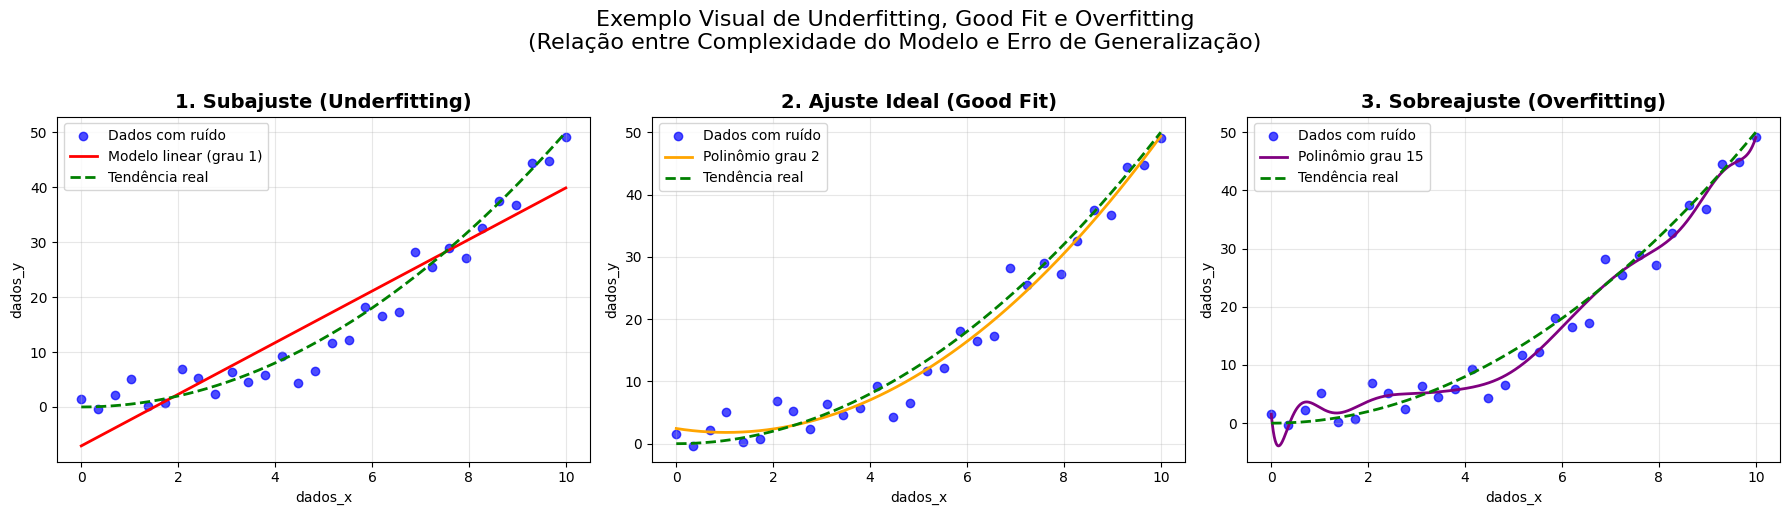

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Configuração para reproducibilidade
np.random.seed(42)

# Geração dos dados sintéticos com tendência quadrática e ruído
intervalo_x = np.linspace(0, 10, 30)
dados_x = intervalo_x
tendencia_real = 0.5 * dados_x ** 2
ruido = np.random.normal(0, 3, len(dados_x))
dados_y = tendencia_real + ruido

# Ponto de avaliação suave para plotar as curvas
x_plot = np.linspace(0, 10, 1000)
tendencia_plot = 0.5 * x_plot ** 2

# 1. Subajuste (Underfitting): Modelo linear (grau 1) - muito simples, alto viés
coef_subajuste = np.polyfit(dados_x, dados_y, 1)
curva_subajuste = np.polyval(coef_subajuste, x_plot)

# 2. Ajuste ideal (Good Fit): Polinômio de grau 2 - complexidade adequada
coef_ideal = np.polyfit(dados_x, dados_y, 2)
curva_ideal = np.polyval(coef_ideal, x_plot)

# 3. Sobreajuste (Overfitting): Polinômio de grau 15 - muito complexo, alta variância
coef_sobreajuste = np.polyfit(dados_x, dados_y, 15)
curva_sobreajuste = np.polyval(coef_sobreajuste, x_plot)

# Criação dos três gráficos comparativos
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Subajuste
axs[0].scatter(dados_x, dados_y, alpha=0.7, color='blue', label='Dados com ruído')
axs[0].plot(x_plot, curva_subajuste, 'red', linewidth=2, label='Modelo linear (grau 1)')
axs[0].plot(x_plot, tendencia_plot, 'green', linestyle='--', linewidth=2, label='Tendência real')
axs[0].set_title('1. Subajuste (Underfitting)', fontsize=14, fontweight='bold')
axs[0].set_xlabel('dados_x')
axs[0].set_ylabel('dados_y')
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# Gráfico 2: Ajuste ideal
axs[1].scatter(dados_x, dados_y, alpha=0.7, color='blue', label='Dados com ruído')
axs[1].plot(x_plot, curva_ideal, 'orange', linewidth=2, label='Polinômio grau 2')
axs[1].plot(x_plot, tendencia_plot, 'green', linestyle='--', linewidth=2, label='Tendência real')
axs[1].set_title('2. Ajuste Ideal (Good Fit)', fontsize=14, fontweight='bold')
axs[1].set_xlabel('dados_x')
axs[1].set_ylabel('dados_y')
axs[1].legend()
axs[1].grid(True, alpha=0.3)

# Gráfico 3: Sobreajuste
axs[2].scatter(dados_x, dados_y, alpha=0.7, color='blue', label='Dados com ruído')
axs[2].plot(x_plot, curva_sobreajuste, 'purple', linewidth=2, label='Polinômio grau 15')
axs[2].plot(x_plot, tendencia_plot, 'green', linestyle='--', linewidth=2, label='Tendência real')
axs[2].set_title('3. Sobreajuste (Overfitting)', fontsize=14, fontweight='bold')
axs[2].set_xlabel('dados_x')
axs[2].set_ylabel('dados_y')
axs[2].legend()
axs[2].grid(True, alpha=0.3)

plt.suptitle('Exemplo Visual de Underfitting, Good Fit e Overfitting\n(Relação entre Complexidade do Modelo e Erro de Generalização)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# COMENTÁRIOS DIDÁTICOS PARA ESTUDANTES DE ENGENHARIA:
#
# - SUBAJUSTE (Underfitting): O modelo linear é muito simples para capturar a tendência quadrática.
#   Resultado: Alto VIÉS (bias) e erro alto tanto no treino quanto na generalização.
#   Lição: Modelos simples falham em aprender padrões complexos.
#
# - AJUSTE IDEAL (Good Fit): Grau 2 combina com a tendência real. Baixo viés e baixa variância.
#   Resultado: Bom desempenho no treino e na generalização (novos dados).
#   Lição: Escolha a complexidade que equilibra viés-variância (Trade-off Bias-Variance).
#
# - SOBREAJUSTE (Overfitting): Grau 15 “aprende” até o ruído aleatório. Perfeito no treino,
#   mas oscila muito e falha na generalização.
#   Resultado: Baixo viés, mas ALTA VARIÂNCIA. Erro alto em dados novos.
#   Lição: Modelos complexos memorizam ruído, não a tendência real. Use validação cruzada,
#   regularização (L1/L2) ou mais dados para mitigar.
#
# Em resumo: Aumentar complexidade reduz viés, mas aumenta variância.
# Objetivo em ML: Minimizar erro total = viés + variância + erro irredutível.

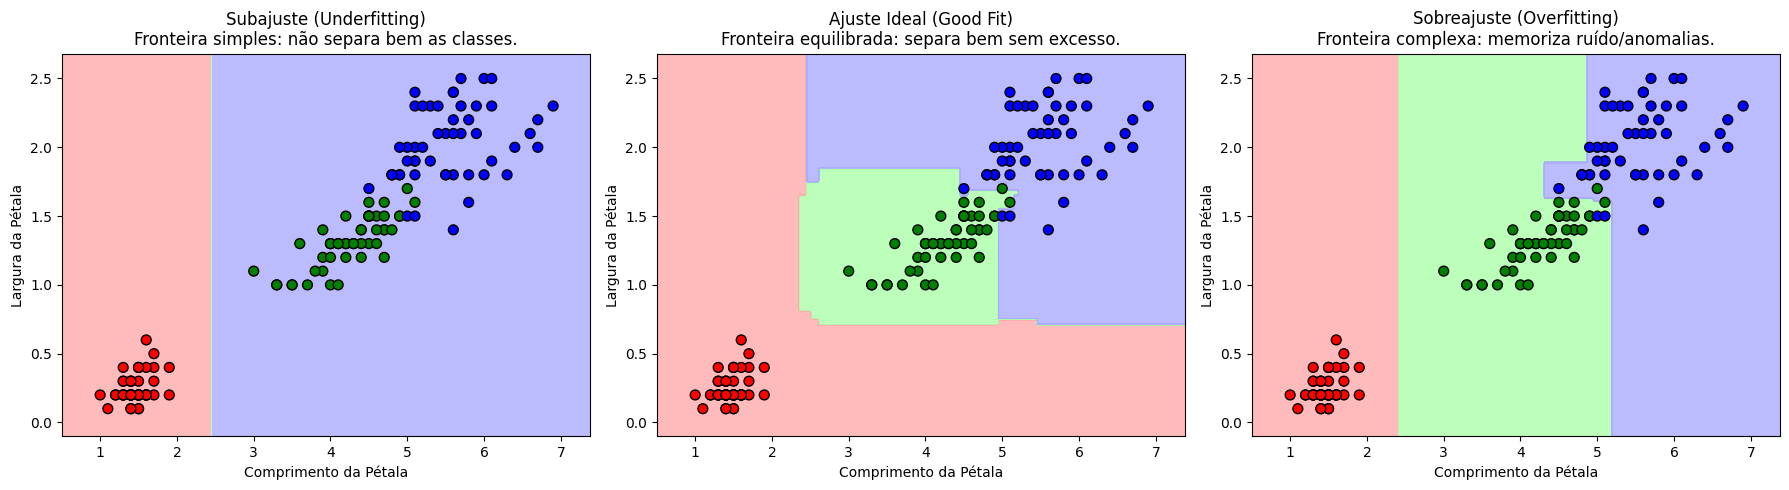

In [3]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Carregar o dataset Iris
dataset_iris = load_iris()
dados = dataset_iris.data
rotulos = dataset_iris.target

# Selecionar apenas duas características para visualização 2D: comprimento e largura da pétala
dados_petala = dados[:, [2, 3]]

# Comentário didático: Usamos duas features para plotar fronteiras de decisão em 2D.
# Iris tem 3 classes: setosa (0), versicolor (1), virginica (2).

# Adicionar ruído artificial aos dados para forçar overfitting no modelo sobreajustado
np.random.seed(42)  # Para reprodutibilidade
dados_ruido = dados_petala + np.random.normal(0, 0.15, dados_petala.shape)

# Treinar os três modelos
# 1. Subajuste (Underfitting): Árvore rasa (Decision Stump, max_depth=1)
#    Fronteira muito simples: alta bias, não captura padrões complexos.
modelo_subajuste = DecisionTreeClassifier(max_depth=1, random_state=42)
modelo_subajuste.fit(dados_petala, rotulos)

# 2. Ajuste Ideal (Good Fit): Random Forest com parâmetros equilibrados
#    Fronteira suave e separadora: baixa bias e variância.
modelo_ideal = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
modelo_ideal.fit(dados_petala, rotulos)

# 3. Sobreajuste (Overfitting): Árvore profunda sem restrições, treinada com ruído
#    Fronteira complexa e irregular: memoriza ruído/anomalias, alta variância.
#    A 'complexidade da fronteira' (muitas divisões wiggly) denuncia o overfitting.
modelo_sobreajuste = DecisionTreeClassifier(random_state=42)
modelo_sobreajuste.fit(dados_ruido, rotulos)

# Criar grid (mesh) para plotar as fronteiras de decisão
h = 0.02  # Passo da malha
x_min, x_max = dados_petala[:, 0].min() - 0.5, dados_petala[:, 0].max() + 0.5
y_min, y_max = dados_petala[:, 1].min() - 0.2, dados_petala[:, 1].max() + 0.2
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Definição de cores distintas para as 3 espécies
cmap_fundo = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])  # Fundo das regiões
cmap_pontos = ListedColormap(['red', 'green', 'blue'])  # Pontos das flores

# Gerar previsões de decisão (limites_decisao) para cada modelo no grid
limites_decisao_sub = modelo_subajuste.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
limites_decisao_ideal = modelo_ideal.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
limites_decisao_sobre = modelo_sobreajuste.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Plotar os três gráficos comparativos
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Subajuste
axs[0].contourf(xx, yy, limites_decisao_sub, alpha=0.8, cmap=cmap_fundo)
axs[0].scatter(dados_petala[:, 0], dados_petala[:, 1], c=rotulos, cmap=cmap_pontos, edgecolors='k', s=50)
axs[0].set_title('Subajuste (Underfitting)\nFronteira simples: não separa bem as classes.')
axs[0].set_xlabel('Comprimento da Pétala')
axs[0].set_ylabel('Largura da Pétala')

# Gráfico 2: Ajuste Ideal
axs[1].contourf(xx, yy, limites_decisao_ideal, alpha=0.8, cmap=cmap_fundo)
axs[1].scatter(dados_petala[:, 0], dados_petala[:, 1], c=rotulos, cmap=cmap_pontos, edgecolors='k', s=50)
axs[1].set_title('Ajuste Ideal (Good Fit)\nFronteira equilibrada: separa bem sem excesso.')
axs[1].set_xlabel('Comprimento da Pétala')
axs[1].set_ylabel('Largura da Pétala')

# Gráfico 3: Sobreajuste
axs[2].contourf(xx, yy, limites_decisao_sobre, alpha=0.8, cmap=cmap_fundo)
axs[2].scatter(dados_petala[:, 0], dados_petala[:, 1], c=rotulos, cmap=cmap_pontos, edgecolors='k', s=50)
axs[2].set_title('Sobreajuste (Overfitting)\nFronteira complexa: memoriza ruído/anomalias.')
axs[2].set_xlabel('Comprimento da Pétala')
axs[2].set_ylabel('Largura da Pétala')

# Comentário didático final: Compare a complexidade das fronteiras!
# - Simples (subajuste): ruim para todos os dados.
# - Suave (ideal): ótimo equilíbrio.
# - Wiggly/irregular (sobreajuste): perfeito para treino com ruído, mas generaliza mal.
plt.tight_layout()
plt.show()